In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
from scipy.signal import resample, correlate, savgol_filter
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, chisquare, spearmanr
from scipy.optimize import Bounds, minimize
from IPython.display import HTML
import pandas as pd
import time
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from matplotlib.animation import FuncAnimation
plt.style.use('ggplot')
from mpl_toolkits.mplot3d import Axes3D


from vtna.metrics import *
from vtna.testing import make_sigs
from vtna.align import grid_search_comp
from vtna.signal import interp_neg_comp, interp_neg, replace_neg, drop_neg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def timer(method):
    def timed(*args, **kw):
        ts = time.time()
        result = method(*args, **kw)
        te = time.time()
        return result, int(round((te - ts) * 1000))
    return timed

def progress(val, start=0, end=100, maxlen=40, hash='#'):
    decimal = val / (end - start)
    progress = decimal * 100
    if progress < 99.999:
        num_hash = int(maxlen * decimal)
        hashes = hash * num_hash + ' ' * (maxlen - num_hash) * len(hash)
        print('\r|'+'{}'.format(hashes)+'| {:.1f}%'.format(progress), end='', flush=True)
    else:
        hashes = hash * maxlen
        print('\r|'+'{}'.format(hashes)+'| DONE!'.format(progress), end='', flush=True)

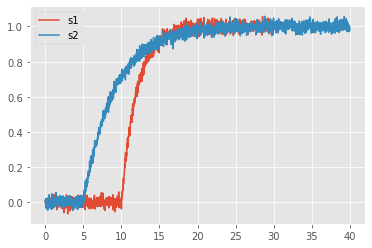

In [5]:
s1, s2 = make_sigs(2, 10, 30, 5, 40, freq=0.02, noise=0.02)
plt.plot(s1[:, 0], s1[:, 1], label='s1')
plt.plot(s2[:, 0], s2[:, 1], label='s2')
plt.legend()
plt.show()

## Aligning 2 Signals, Method 1: Grid Search over Translation and Compression

Actual Compression 0.5, followed by translation of 7.5, to perfectly overlap nois-free signals.
Best fit achieved for a compression of 0.49 and subsequent translation of 7.54 applied to signal 2.


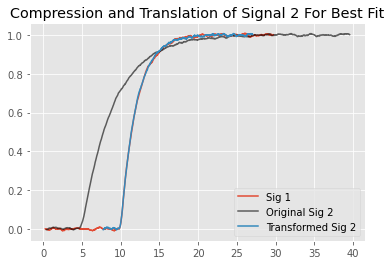

CPU times: user 449 ms, sys: 7.84 ms, total: 457 ms
Wall time: 456 ms


<Figure size 432x288 with 0 Axes>

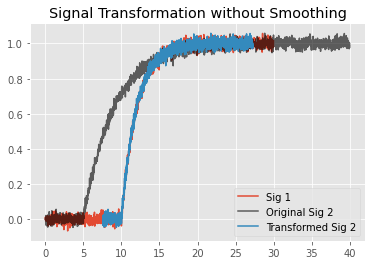

In [9]:
print('Actual Compression 0.5, followed by translation of 7.5, to perfectly overlap nois-free signals.')
%time shift_t, comp = grid_search_comp(s1, s2, smooth=True, smooth_mode='derivative', win1=None, win2=None, plot=True, comp_res=0.01, comp_tol=0.01, truncate=False)
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(s1[:, 0], s1[:, 1], label='Sig 1')
ax.plot(s2[:, 0], s2[:, 1], c='k', alpha=0.6, label='Original Sig 2')
ax.plot(s2[:, 0]*comp + shift_t, s2[:, 1], label='Transformed Sig 2')
ax.legend()
ax.set_title('Signal Transformation without Smoothing')
plt.show()

# Handling Negative Values

With added noise, sometimes a signal may have negative values, which is not physical when the signal corresponds to the concentration of a chemical species. We can treat these negative values in one of three ways: 

1. Remove that value from the signal (`vtna.signal.drop_neg`)
2. Relace that value with some preset, e.g. 0 (`vtna.signal.replace_neg`)
3. Interpolate the value using neighboring values (`vtna.signal.interp_neg`, `vtna.signal.interp_neg_comp`)

Here we look at `vtna.signal.interp_neg` and `vtna.signal.interp_neg_comp`, which can use linear, nearest_neighbor, linear spline, quadratic spline, or cubic spline interpolation.

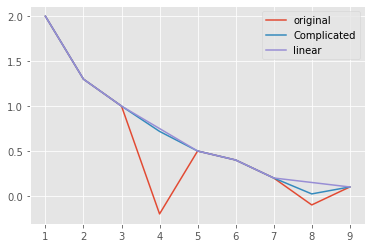

In [12]:
from vtna.signal import interp_neg_comp, interp_neg, replace_neg, drop_neg

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([2,1.3,1,-0.2,0.5, 0.4, 0.2, -0.1, 0.1])
plt.plot(x, y, label='original')
    
y_2 = y.copy()
interp_neg_comp(x,y_2, method='cubic')
plt.plot(x,y_2, label="Complicated")

interp_neg(x,y)
plt.plot(x,y, label='linear')
plt.legend()
plt.show()

# Evaluate Interpolation Speed

Here is just a quick evaluation of the interpolation procedure speed. Note that `interp_neg_comp` uses the `scipy.interpolate.interp1d` function under the hood, whereas `interp_neg` uses `numpy.interp`, which performs a linear interpolation only. The numpy procedure is about 10 times faster for this simple example even when the method in `interp_neg_comp` is set to 'linear'. Higher order interpolation schemes also slow the scipy procedure.

In [13]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([2,1.3,1,-0.2,0.5, 0.4, 0.2, -0.1, 0.1])

In [14]:
%%timeit
y_2 = y.copy()
interp_neg_comp(x,y_2, method='linear')

112 µs ± 2.15 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [15]:
%%timeit
y_2 = y.copy()
interp_neg_comp(x,y_2, method='cubic')

263 µs ± 12.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [16]:
%%timeit
y_2 = y.copy()
interp_neg(x,y_2)

11.4 µs ± 463 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## Interpolate Negative Values

Here we test how well the different schemes for handling negative numbers perform when normalizing a reaction trace time. To do so, we generate fake reaction trace for the decomposition of N2O5 to NO and O2, with first order kinetics. We add noise and apply one of the 3 procedures enumerated above for handling negative values. Then we normalize the time for the O2 trace by the proper reaction order, which should reduce the O2 data to a line when plotted against the normalized time. We measure performance by performing a least squares linear regression and computing the $R^2$ value. We perform this 2000 times for each procedure for handling negative numbers and report the average $R^2$ value. A better procedure will result in the highest average $R^2$ value. 

In [20]:
from vtna.vtna import normalize_time

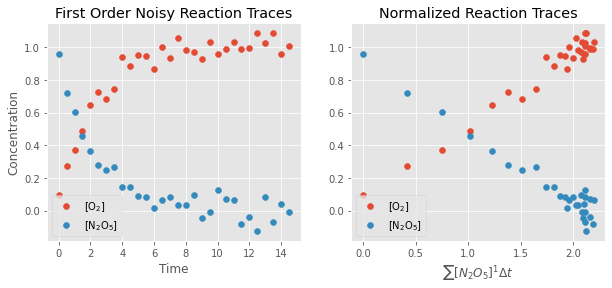

In [23]:
O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.05)
tO2, O2 = O2[:,0], O2[:,1]
tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

# flip sig 2
N2O5 = 1 - N2O5

# normalize product (O2) time axis wrt N2O5
tO2_norm =  normalize_time(tO2, N2O5, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.scatter(tO2, O2, label='[O$_2$]')
ax1.scatter(tO2, N2O5, label='[N$_2$O$_5$]')
ax1.legend()
ax1.set_xlabel('Time')
ax1.set_ylabel('Concentration')
ax1.set_title('First Order Noisy Reaction Traces')
ax2.scatter(tO2_norm, O2, label='[O$_2$]')
ax2.scatter(tO2_norm, N2O5, label='[N$_2$O$_5$]')
ax2.legend()
ax2.set_title('Normalized Reaction Traces')
ax2.set_xlabel('$\sum{[N_2O_5]^1\Delta t}$')
plt.show()

## Interpolate Negative With Linear Interpolation

In [24]:
# %%timeit -n 1
N = 2000
rs = np.zeros(N)
for i in range(N):
    # 2 N2O5(g) --> 4 NO(g) + O2(g), Rate = k[N2O5]
    O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.05)
    tO2, O2 = O2[:,0], O2[:,1]
    tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

    # flip sig 2
    N2O5 = 1 - N2O5
    
    # interpolate negative values:
    interp_neg(tO2, N2O5)
    interp_neg(tO2, O2)
    
    # normalize product (O2) time axis wrt N2O5
    tO2_norm =  normalize_time(tO2, N2O5, 1)

    tO2_norm_reg = tO2_norm.reshape(-1,1)
    O2_reg = O2.reshape(-1,1)

    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, O2_reg)
    rs[i] = line.score(tO2_norm_reg, O2_reg)
print(rs.mean())

0.939740086232865


## Replace Negative Values with 0

In [25]:
# %%timeit -n 1
N = 2000
rs = np.zeros(N)
for i in range(N):
    # 2 N2O5(g) --> 4 NO(g) + O2(g), Rate = k[N2O5]
    O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.05)
    tO2, O2 = O2[:,0], O2[:,1]
    tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

    # flip sig 2
    N2O5 = 1 - N2O5
    
    # remove negative values:
    replace_neg(N2O5)
    #replace_neg(O2)
    
    # normalize product (O2) time axis wrt N2O5
    tO2_norm =  normalize_time(tO2, N2O5, 1)

    tO2_norm_reg = tO2_norm.reshape(-1,1)
    O2_reg = O2.reshape(-1,1)

    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, O2_reg)
    rs[i] = line.score(tO2_norm_reg, O2_reg)
print(rs.mean())

0.9556435585539126


## Remove Negative Values

In [26]:
# %%timeit -n 1
N = 2000
rs = np.zeros(N)
for i in range(N):
    # 2 N2O5(g) --> 4 NO(g) + O2(g), Rate = k[N2O5]
    O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.05)
    tO2, O2 = O2[:,0], O2[:,1]
    tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

    # flip sig 2
    N2O5 = 1 - N2O5
    
    # remove negative values:
    concs = np.array([N2O5, O2]).T
    tO2, concs = drop_neg(tO2, concs)
    N2O5 = concs[:, 0]
    O2 = concs[:, 1] 
    
    # normalize product (O2) time axis wrt N2O5
    tO2_norm =  normalize_time(tO2, N2O5, 1)

    tO2_norm_reg = tO2_norm.reshape(-1,1)
    O2_reg = O2.reshape(-1,1)

    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, O2_reg)
    rs[i] = line.score(tO2_norm_reg, O2_reg)
print(rs.mean())

0.9389726101902057


## Leave Negative Values

In [27]:
#%%timeit -n 1
N = 2000
rs = np.zeros(N)
for i in range(N):
    # 2 N2O5(g) --> 4 NO(g) + O2(g), Rate = k[N2O5]
    O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.05)
    tO2, O2 = O2[:,0], O2[:,1]
    tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

    # flip sig 2
    N2O5 = 1 - N2O5
    
    # normalize product (O2) time axis wrt N2O5
    tO2_norm =  normalize_time(tO2, N2O5, 1)

    tO2_norm_reg = tO2_norm.reshape(-1,1)
    O2_reg = O2.reshape(-1,1)

    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, O2_reg)
    rs[i] = line.score(tO2_norm_reg, O2_reg)
print(rs.mean())

0.9566496710304239


## Results

The best procedure for fitting is to simply leave in negative values in the signal. However, this sometimes leads to errors in other interpolation procedures later in this notebook. It seems that the next best procedure is to simply replace negative values with 0, at least for the noise levels surveyed here.

## Examine Different Smoothing Algorithms
**1. Rolling Average:** Simply take the mean of a small window of points and report that value as the signal value for the center of the widow.

**2. Rolling Average with Window Filter:** Convolve a function defined over some small window with your signal. The function may be a Gaussian or a Blackman function. The result is a rolling average as above, but with a larger weighting for the points in the center of the window. The rolling mean above could be defined this way, too, but with a uniform function f(x) = 1/M as the window function, where M is the width of the window.

**3. LOWESS Smoothing:** LOcally WEighted Scatterplot Smoothing. Slide a window along the data and fit a curve to the local window at each point.

**4. Low Pass Filter:** Noise presents as high-frequency components of the signal. Can remove these with a *Butterworth filter*. 

In [131]:
from scipy import signal
from statsmodels.nonparametric.smoothers_lowess import lowess
from vtna.signal import rolling_mean, x_rolling, smooth

In [158]:
# Signals to test on
O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.1, noise=0.1)
O2_real, _ = make_sigs(1, 0, 15, 0, 15, freq=0.1, noise=0)
_, O2_real = O2_real[:,0], O2_real[:,1]
tO2, O2 = O2[:,0], O2[:,1]
replace_neg(O2, 0.)

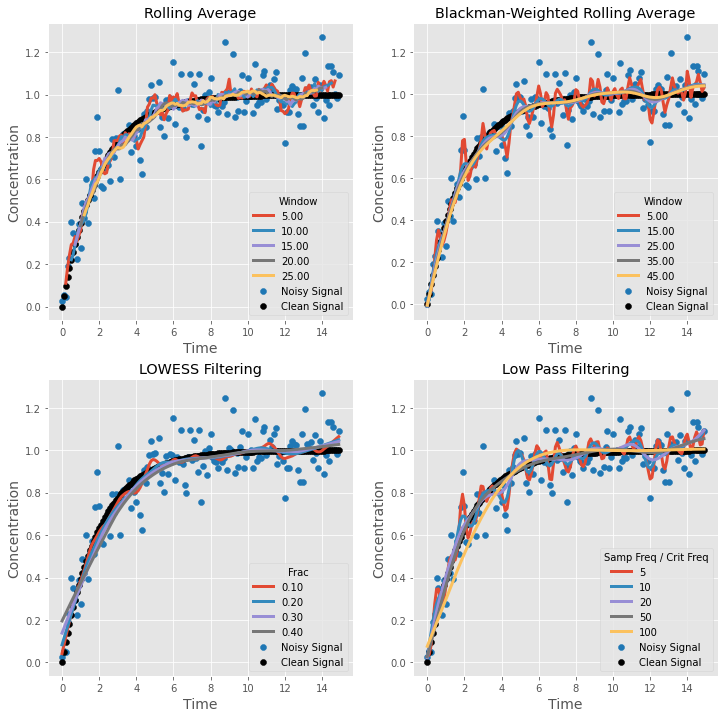

In [160]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))

for ax in [ax1, ax2, ax3, ax4]:
    ax.scatter(tO2, O2, c='tab:blue', label="Noisy Signal")
    ax.scatter(tO2, O2_real, c='k', label="Clean Signal")

# Simple Rolling Average
for win in np.arange(5, 30, 5):
    roll = rolling_mean(O2, win=win)
    x = x_rolling(tO2, win=win)
    ax1.plot(x, roll, linewidth=3, label=f"{win:0.2f}")
ax1.legend(title="Window")
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('Rolling Average') 

# Rolling Average with Blackman Window
for win in np.arange(5, 50, 10):
    b_roll = smooth(O2,window_len=win,window='blackman')
    ax2.plot(tO2, b_roll, linewidth=3, label=f"{win:0.2f}")
ax2.legend(title="Window")
ax2.set_xlabel('Time', fontsize=14)
ax2.set_ylabel('Concentration', fontsize=14)
ax2.set_title('Blackman-Weighted Rolling Average') 
      
# LOWESS Filter      
for frac in np.arange(0.1, 0.5, 0.1):
    filtered = lowess(O2, tO2, frac=frac)
    ax3.plot(filtered[:, 0], filtered[:, 1], linewidth=3, label=f"{frac:0.2f}")
ax3.legend(title="Frac")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('LOWESS Filtering')
      
# Low-Pass Filter
order = 3
samp_per = 0.1
for divider in [5, 10, 20, 50, 100]:
    crit_freq = 1/samp_per / divider
    b, a = signal.butter(order, crit_freq, btype='lowpass', analog=False, fs=1/samp_per)
    low_passed = signal.filtfilt(b, a, O2)
    ax4.plot(tO2, low_passed, linewidth=3, label=f"{divider}")
ax4.legend(title="Samp Freq / Crit Freq")
ax4.set_xlabel('Time', fontsize=14)
ax4.set_ylabel('Concentration', fontsize=14)
ax4.set_title('Low Pass Filtering')
      
plt.show()

## Evaluating the Best Smoothing Algorithms

From the preliminary analysis above, it seems that using a window filter or a simple low-pass filter, produces the best results. Now, let's examine this quantitatively to see which filter produces the best correlation with the original noiseless signal.

In [162]:
from scipy.optimize import minimize
from vtna.metrics import pear_r

In [193]:
def objective_blackman(window, noisy, no_noise):
    filtered = smooth(noisy, window_len=window, window='blackman')
    return -abs(pear_r(no_noise, filtered))

def objective_lowpass(divider, noisy, no_noise, samp_per, order):
    crit_freq = 1 / samp_per / divider
    b, a = signal.butter(order, crit_freq, btype='lowpass', analog=False, fs=1/samp_per)
    low_passed = signal.filtfilt(b, a, O2)
    return -abs(pear_r(no_noise, low_passed))

In [240]:
# Noise-Free
samp_per = 0.1
O2_real, _ = make_sigs(1, 0, 15, 0, 15, freq=0.1, noise=0)
_, O2_real = O2_real[:,0], O2_real[:,1]

# for different noise levels
rs_blackman = []
wins_blackman = []
rs_lowpass = []
dividers_lowpass = []
noises = np.arange(0, 0.1, 0.005)

for noise in noises:
    # Signals to test on
    O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.1, noise=noise)
    tO2, O2 = O2[:,0], O2[:,1]
    replace_neg(O2, 0.)

    obj_blackman = 0
    opt_win_blackman = 0
    for win in range(len(O2)):
        obj = objective_blackman(win, O2, O2_real)
        if obj < obj_blackman:
            obj_blackman = obj
            opt_win_blackman = win
    rs_blackman.append(obj_blackman)
    wins_blackman.append(opt_win_blackman)
    
    result_lowpass = minimize(objective_lowpass, 50, method='BFGS', args=(O2, O2_real, samp_per, 3), bounds=[(2, np.inf)], options={'disp': False})
    rs_lowpass.append(result_lowpass.fun)
    dividers_lowpass.append(result_lowpass.x[0])

/Users/bhenders/.local/lib/python3.8/site-packages/scipy/optimize/_minimize.py:535: RuntimeWarning: Method BFGS cannot handle constraints nor bounds.
  warn('Method %s cannot handle constraints nor bounds.' % method,


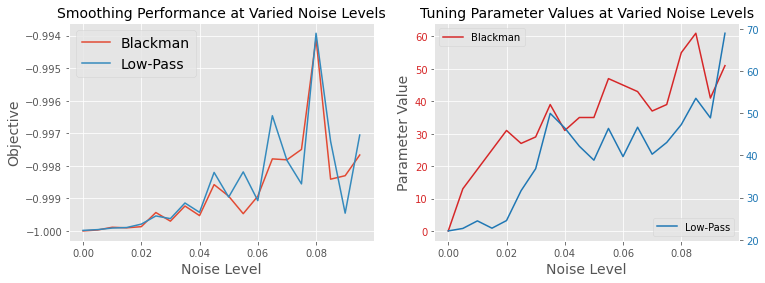

In [241]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(noises, rs_blackman, label='Blackman')
ax1.plot(noises, rs_lowpass, label='Low-Pass')
ax1.set_xlabel('Noise Level', fontsize=14)
ax1.set_ylabel('Objective', fontsize=14)
ax1.set_title('Smoothing Performance at Varied Noise Levels', fontsize=14)
ax1.legend(fontsize=14)

ax2.plot(noises, wins_blackman, c='tab:red', label='Blackman')
ax3 = ax2.twinx()
ax3.grid(False)
ax3.plot(noises, dividers_lowpass, c='tab:blue', label='Low-Pass')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax3.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper left')
ax3.legend(loc='lower right')
ax2.set_xlabel('Noise Level', fontsize=14)
ax2.set_ylabel('Parameter Value', fontsize=14)
ax2.set_title('Tuning Parameter Values at Varied Noise Levels', fontsize=14)

plt.show()

# I. Design Algorithm to Compute Total Reaction Order

Now that we've surveyed some ways to align signals, perform time normalization, and handle negative values, we can try to find the optimal time normalization programmatically. For the case of a reaction with a single species in the rate law, this process can be approached from a VTNA perspective as a simple global search over all possible reaction orders to find the one that produces the most linear normalized curve. We use a procedure similar to the above:

1. Normalize the time for the curve by the appropriate species from the assumed rate law with order **o**.
2. Perform a linear regression on the plot of the species concentration against the normalized time and compute $R^2$
3. Find the order **o**$_{opt}$ that produces the largest |$R^2$| closest to 1.

## a.)  Exhaustive Search Over Reaction Orders

The naive implementation is just a grid search over reasonable values of reaction order.

In [28]:
from vtna.vtna import VTNA_1D

In [31]:
o_opt, _ = VTNA_1D(tO2.flatten(), O2.flatten(), N2O5.flatten(), sm=False)

print(f"The estimated reaction order of N2O5 is {o_opt}, whereas the true order is 1")

The estimated reaction order of N2O5 is 1.06, whereas the true order is 1


## c.) Actual "Optimization": Use Scipy's Minimize Function

### (i) Minimization Using Nelder-Meade Algorithm

In [32]:
from vtna.vtna import VTNA

### (ii) Static Figure Showing the Processes of Optimization

**Single Reactant, First Order**
<br>

$$2N_2O_5(g) \rightarrow 4NO(g) + O_2(g)\;, \;\;Rate = k[N_2O_5]$$

<br>
This simulated reaction will be used as an example in the next few cells as a proof of concept of the algorithm's abilities and also as a demonstration of how it works.

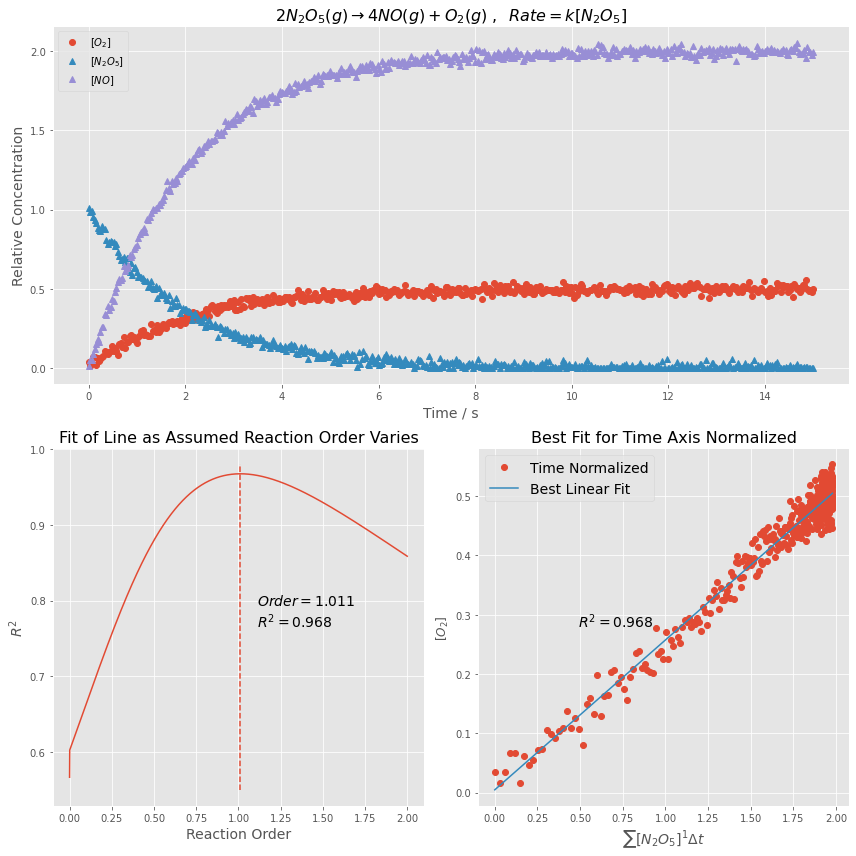

In [210]:
%matplotlib inline

np.random.seed(0)

o = 1
noise = 0.02
k = 0.25
time = np.linspace(0, 15, 500)
dts = time[1:] - time[:-1]
N2O5 = [1.0]
O2 = [0.]
NO = [0.]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*N2O5[i]**o
    
    # calculate the amount of each species
    N2O5.append(N2O5[i] - dt * 2 * rate)
    O2.append(O2[i] + dt * rate)
    NO.append(NO[i] + dt * 4 * rate)

O2, N2O5, NO = np.array(O2), np.array(N2O5), np.array(NO)

# Add noise
O2 += np.random.normal(0,noise,len(time))
N2O5 += np.random.normal(0,noise,len(time))
NO += np.random.normal(0,noise,len(time))

# flip sig 2
# N2O5 = 1 - N2O5

# replace all negative values of the signals with 0, since these sometimes produce NaN during normalization
replace_neg(N2O5, val=0)

rs = []
bestr = 0
besto = 0
best_norm = None
best_line = None
res=0.001

for order in np.arange(o-1, o+1, res):
    # normalize product (O2) time axis wrt N2O5 with guessed value for order
    t_norm =  normalize_time(time, N2O5, order)
    t_norm = t_norm.reshape(-1,1)
    
    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(t_norm, O2)
    r = line.score(t_norm, O2)
    rs.append(line.score(t_norm, O2))
    
    if abs(r) > abs(bestr):
        bestr = r
        best_norm = t_norm
        besto = order
        best_line = line
    
fig = plt.figure(figsize=(12,12))
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(time, O2, 'o', label='$[O_2]$')
ax1.plot(time, N2O5, '^', label='$[N_2O_5]$')
ax1.plot(time, NO, '^', label='$[NO]$')
ax1.legend()
ax1.set_title(r'$2N_2O_5(g) \rightarrow 4NO(g) + O_2(g)\;, \;\;Rate = k[N_2O_5]$', fontsize=16)
ax1.set_xlabel('Time / s', fontsize=14)
ax1.set_ylabel('Relative Concentration', fontsize=14)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.arange(o-1, o+1, res), rs)
ax3.set_title('Fit of Line as Assumed Reaction Order Varies', fontsize=16)
ax3.set_xlabel('Reaction Order', fontsize=14)
ax3.set_ylabel('$R^2$', fontsize=14)
ax3.vlines(besto, ymin=0.55, ymax=0.98, linestyles='--')
ax3.text(0.55, 0.5, "$Order={:.3f}$ \n$R^2={:.3f}$".format(besto, bestr), transform=ax3.transAxes, fontsize=14)
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(best_norm, O2, 'o', label="Time Normalized")
ax4.plot(best_norm, best_line.predict(best_norm), label="Best Linear Fit")
ax4.legend(fontsize=14)
ax4.set_title('Best Fit for Time Axis Normalized', fontsize=16)
ax4.set_xlabel('$\sum{[N_2O_5]^1\Delta t}$', fontsize=14)
ax4.set_ylabel("$[O_2]$")
ax4.text(0.27, 0.5, "$R^2={:.3f}$".format(bestr), transform=ax4.transAxes, fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# fig.savefig('figures/sample_first_order_n2o5_decomp.svg', dpi=300)

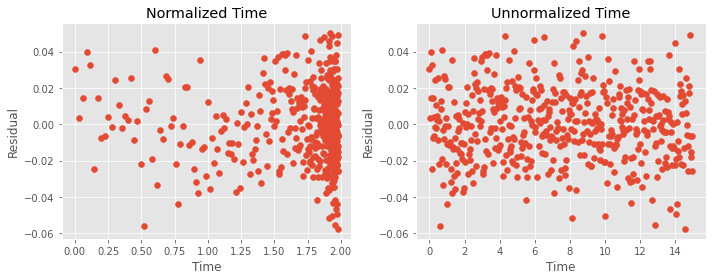

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
resid = O2 - best_line.predict(best_norm)
ax1.scatter(best_norm, resid)
ax1.set_title('Normalized Time')
ax2.scatter(time, resid)
ax2.set_title('Unnormalized Time')
for ax in (ax1, ax2):
    ax.set_xlabel('Time')
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.show()

In [201]:
from scipy.optimize import curve_fit

In [217]:
def simple_exponential(t, c0, k):
    return c0 * np.exp(-k*t)

popt, pcov = curve_fit(simple_exponential, time, N2O5)

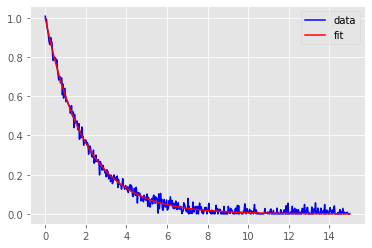

In [219]:
plt.plot(time, N2O5, 'b-', label='data')
plt.plot(time, simple_exponential(time, *popt), 'r-', label='fit')
plt.legend()

### (iii) Create An Animation of the Optimization Algorithm

In [100]:
params = []
def save_params_cb(xk):
    params.append(xk)
    
np.random.seed(0)

O2, N2O5 = make_sigs(1, 0, 15, 0, 15, freq=0.5, noise=0.0)
tO2, O2 = O2[:,0], O2[:,1]
tN2O5, N2O5 = N2O5[:,0], N2O5[:,1]

# flip sig 2
N2O5 = 1 - N2O5
#tO2 = time

N2O5_decomp = VTNA(tO2, O2, N2O5)
# N2O5_decomp.smooth_data(win=5, win_type='blackman')

N2O5_decomp.optimize(np.array([0]), 
                     method='nelder-mead', 
                     options={'xatol': 1e-2, 'fatol': 1e-5, 'disp': True})

o = 1
rs = []
bestr = 0
besto = 0
best_norm = None
best_line = None
res=0.01

for order in np.arange(o-1, o+1, res):
    # normalize product (O2) time axis wrt N2O5 with guessed value for order
    t_norm =  normalize_time(tN2O5, N2O5, order)
    t_norm = t_norm.reshape(-1,1)
    
    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(t_norm, O2)
    r = line.score(t_norm, O2)
    rs.append(line.score(t_norm, O2))
    
    if abs(r) > abs(bestr):
        bestr = r
        best_norm = t_norm
        besto = order
        best_line = line
        
print(f'The Reaction Order is estimated to be {besto}.')

Optimization terminated successfully.
         Current function value: -1.000000
         Iterations: 19
         Function evaluations: 38
The Reaction Order is estimated to be 1.0.


/Users/bhenders/.local/lib/python3.8/site-packages/matplotlib/animation.py:973: UserWarning: Animation was deleted without rendering anything. This is most likely unintended. To prevent deletion, assign the Animation to a variable that exists for as long as you need the Animation.
  warnings.warn(


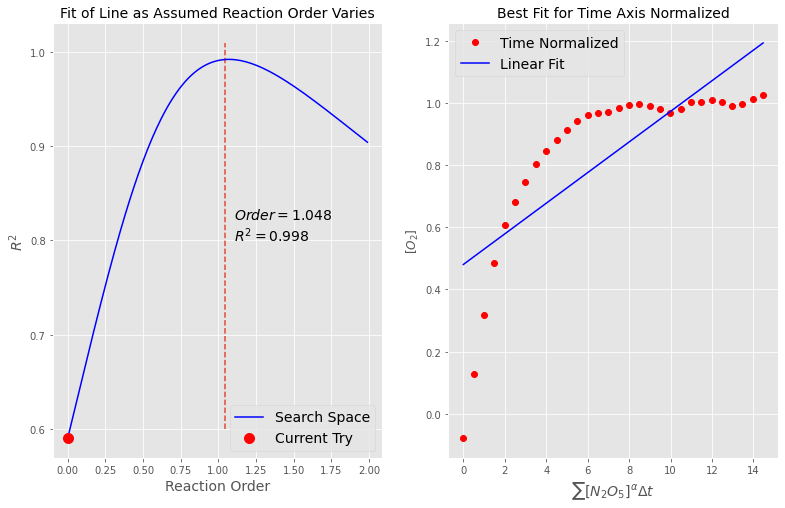

In [64]:
orders = np.arange(0, 2, res)  # the trial space of reaction orders
idx = 0
besto = N2O5_decomp.get_orders()[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 8))
ax1.set_title('Fit of Line as Assumed Reaction Order Varies', fontsize=14)
ax1.set_xlabel('Reaction Order', fontsize=14)
ax1.set_ylabel('$R^2$', fontsize=14)
vline = ax1.vlines(besto, ymin=0.6, ymax=1.01, linestyles='--')
text = ax1.text(0.55, 0.5, "$Order={:.3f}$ \n$R^2={:.3f}$".format(N2O5_decomp.orders[0], - N2O5_decomp.order_score(N2O5_decomp.orders)), transform=ax1.transAxes, fontsize=14)
r2line = ax1.plot(orders, rs[:len(orders)], 'b-', label='Search Space')[0]
coord = ax1.plot([0], [rs[idx]], 'ro', markersize=10, label="Current Try")[0]

# plot the initial scatter from time norm
tO2_norm =  normalize_time(N2O5_decomp.time, N2O5_decomp.normwith, N2O5_decomp.opt_history[0])
tO2_norm_reg = tO2_norm.reshape(-1,1)
line = LinearRegression().fit(tO2_norm_reg, N2O5_decomp.tonorm)
vtna = ax2.plot(tO2_norm, N2O5_decomp.tonorm, 'ro', label="Time Normalized")[0]
fit = ax2.plot(tO2_norm, line.predict(tO2_norm_reg), 'b-', label="Linear Fit")[0]
ax2.set_title('Best Fit for Time Axis Normalized', fontsize=14)
ax2.set_xlabel('$\sum{[N_2O_5]^\\alpha\Delta t}$', fontsize=14)
ax2.set_ylabel("$[O_2]$")

# keep track of all plotted data
patches = [vline] + [text] + [r2line] + [coord] + [vtna] + [fit]

def init():
    ax1.legend(fontsize=14)
    ax2.legend(fontsize=14)
    return patches

def update(idx):
    order = N2O5_decomp.opt_history[idx]
    
    # normalize product (O2) time axis wrt N2O5 with guessed value for order
    tO2_norm =  normalize_time(N2O5_decomp.time, N2O5_decomp.normwith, order)
    tO2_norm_reg = tO2_norm.reshape(-1,1)
    
    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, N2O5_decomp.tonorm)
    score = line.score(tO2_norm_reg, N2O5_decomp.tonorm)
    coord.set_data([order], [score])
    
    vtna.set_data(tO2_norm, N2O5_decomp.tonorm)
    fit.set_data(tO2_norm, line.predict(tO2_norm_reg))
    
    ax2.set_xlim(tO2_norm[0] - 0.1, tO2_norm[-1] * 1.1)
    ax2.figure.canvas.draw()

    
    return patches

ani = FuncAnimation(fig, update, frames=range(len(N2O5_decomp.opt_history)), interval=250, init_func=init, blit=True)

In [38]:
HTML(ani.to_html5_video())

In [39]:
ani.save('figures/1D_Nelder_Meade_fast.gif', writer='imagemagick', fps=4)

### (iv) Create an Animation of the Less Efficient Exhaustive Search Method

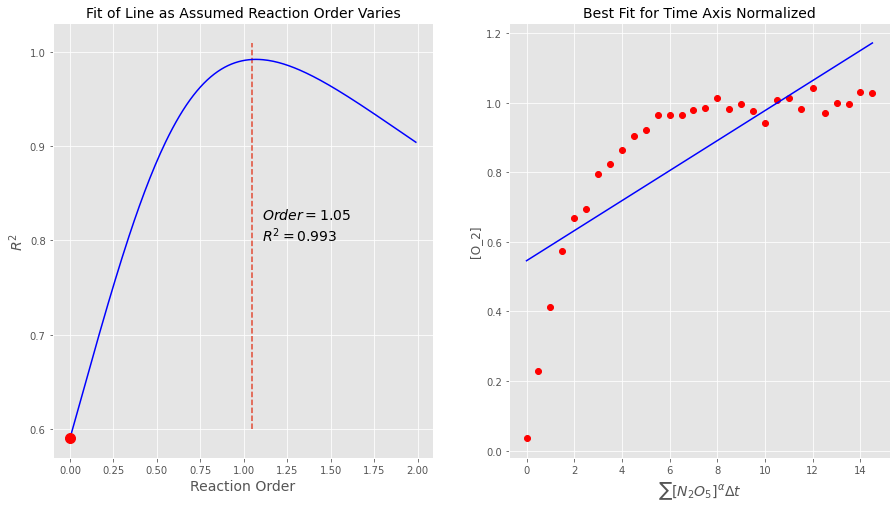

In [73]:
orders = np.arange(0, 2, res)  # the trial space of reaction orders
idx = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.set_title('Fit of Line as Assumed Reaction Order Varies', fontsize=14)
ax1.set_xlabel('Reaction Order', fontsize=14)
ax1.set_ylabel('$R^2$', fontsize=14)
vline = ax1.vlines(besto, ymin=0.6, ymax=1.01, linestyles='--')
text = ax1.text(0.55, 0.5, "$Order={:.2f}$ \n$R^2={:.3f}$".format(besto, bestr), transform=ax1.transAxes, fontsize=14)
r2line = ax1.plot(orders, rs[:len(orders)], 'b-', label='Search Space')[0]
coord = ax1.plot([0], [rs[idx]], 'ro', markersize=10, label="Current Try")[0]

# plot the initial scatter from time norm
tO2_norm = normalize_time(N2O5_decomp.time.reshape(-1,1), N2O5_decomp.normwith, 0)
tO2_norm_reg = tO2_norm.reshape(-1,1)
line = LinearRegression().fit(tO2_norm_reg, O2)
vtna = ax2.plot(tO2_norm, O2, 'ro', label="Time Normalized")[0]
fit = ax2.plot(tO2_norm, line.predict(tO2_norm_reg), 'b-', label="Linear Fit")[0]
ax2.set_title('Best Fit for Time Axis Normalized', fontsize=14)
ax2.set_xlabel('$\sum{[N_2O_5]^\\alpha\Delta t}$', fontsize=14)
ax2.set_ylabel("[O_2]")

# keep track of all plotted data
patches = [vline] + [text] + [r2line] + [coord] + [vtna] + [fit]

def init():
    ax1.legend(fontsize=14)
    ax2.legend(fontsize=14)
    return patches

def update(order):
    global idx
    
    idx += 1
    # normalize product (O2) time axis wrt N2O5 with guessed value for order
    tO2_norm =  normalize_time(N2O5_decomp.time.reshape(-1,1), N2O5_decomp.normwith, order)
    tO2_norm_reg = tO2_norm.reshape(-1,1)
    
    # perform linear regression and calculate R^2
    line = LinearRegression()  
    line.fit(tO2_norm_reg, O2)
    coord.set_data([order], rs[idx])
    
    vtna.set_data(tO2_norm, O2)
    fit.set_data(tO2_norm, line.predict(tO2_norm_reg))
    
    ax2.set_xlim(tO2_norm[0] - 0.1, tO2_norm[-1] * 1.1)
    ax2.figure.canvas.draw()

    
    return patches

ani = FuncAnimation(fig, update, frames=orders[1:], interval=20, init_func=init, blit=False)

In [67]:
HTML(ani.to_html5_video())

In [47]:
from matplotlib.animation import PillowWriter

In [75]:
idx = 0    # must reset frame index, since it's a global variable
#writergif = PillowWriter(fps=10) 
#ani.save('figures/1D_search.gif', writer=writergif)
ani.save('figures/1D_search.gif', writer='imagemagick', fps=5)

# II. Generalization of Optimization To Multiple Dimensions

Most reaction data will require us to normalize the time axis against multiple reagents, each with their own order.  This means each sought reaction order is a coordinate, or dimension, of our search space.  Searching for two reactant orders is a 2-Dimensional minimization problem, and so forth.

As a proof of concept and demonstration of how the algorithm works in 2 dimensions, we choose as a model reaction the following **Order 3 Reaction:**

<br>

$$2NO + O_2 \rightarrow 2NO_2\;,\;\;Rate=k[NO]^2[O_2]$$

We artificially set the rate constant to 2, and then simulate the reaction with the addition of normally distributed noise.  The reaction is simulated such that there is no reverse reaction rate. The plots below show the two reactants that appear in the rate law being successively normalized out of the time axis. After both have been successfully treated, the reaction trace is linear against the normalized time axis, as expected.

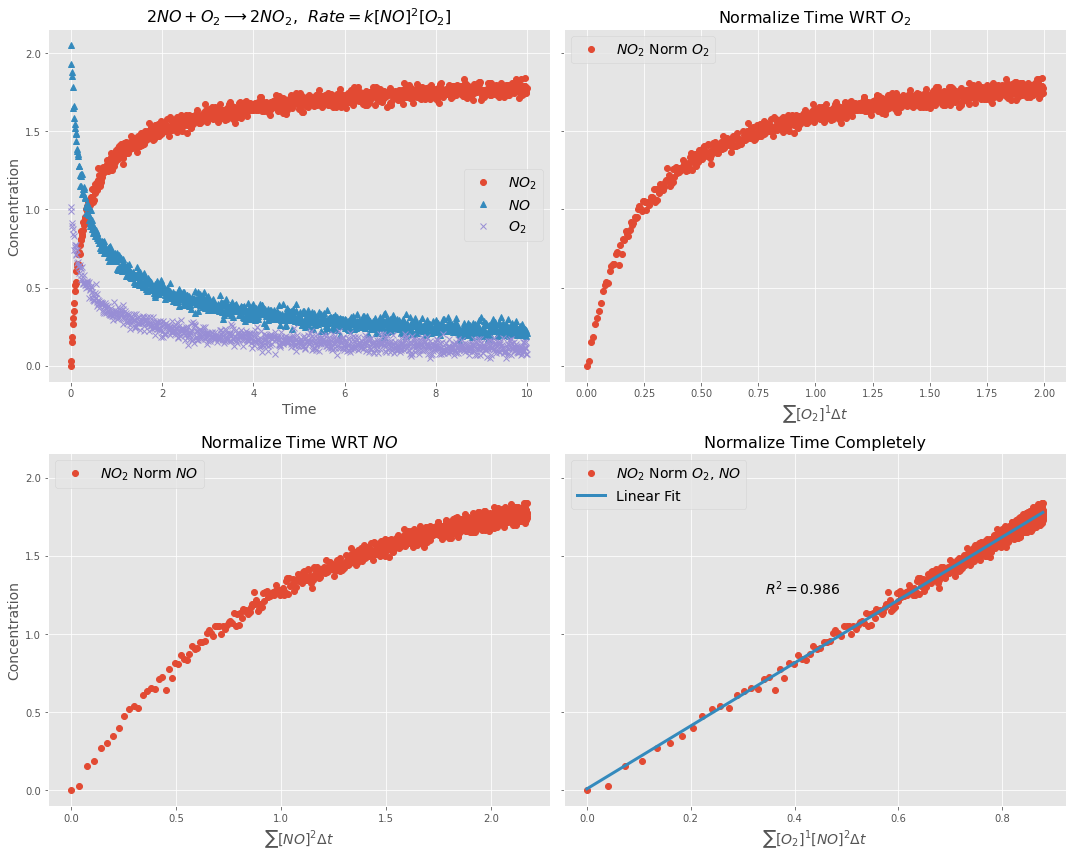

In [292]:
np.random.seed(0)

k = 1
time = np.linspace(0, 10, 1000)
dts = time[1:] - time[:-1]
NO = [2]
O2 = [1]
NO2 = [0]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*NO[i]**2*O2[i]
    
    # calculate the amount of each species
    NO.append(NO[i] - dt * 2 * rate)
    O2.append(O2[i] - dt * rate)
    NO2.append(NO2[i] + dt * 2 * rate)

NO, O2, NO2 = np.array(NO), np.array(O2), np.array(NO2)
NO += np.random.normal(0,0.03,len(time))
O2 += np.random.normal(0,0.03,len(time))
NO2 += np.random.normal(0,0.03,len(time))
replace_neg(NO2, 0)

# plot it    
fig, ax = plt.subplots(2, 2, figsize=(15, 12), sharey=True)
ax1, ax2, ax3, ax4 = ax.flatten()
ax1.plot(time, NO2, 'o', label="$NO_2$")
ax1.plot(time, NO, '^', label="$NO$")
ax1.plot(time, O2, 'x', label="$O_2$")
ax1.set_title("$2NO + O_2 \longrightarrow 2NO_2$,  $Rate=k[NO]^2[O_2]$", fontsize=16)
ax1.set_xlabel("Time", fontsize=14)
ax1.set_ylabel("Concentration", fontsize=14)
ax1.legend(fontsize=14)

tO2_norm =  normalize_time(time, O2, 1)
ax2.plot(tO2_norm, NO2, 'o', label='$NO_2$ Norm $O_2$')
ax2.set_title('Normalize Time WRT $O_2$', fontsize=16)
ax2.set_xlabel('$\sum{[O_2]^1\Delta t}$', fontsize=14)
ax2.legend(loc='upper left', fontsize=14)

tNO_norm =  normalize_time(time, NO, 2)
ax3.plot(tNO_norm, NO2, 'o', label='$NO_2$ Norm $NO$')
ax3.set_title('Normalize Time WRT $NO$', fontsize=16)
ax3.set_xlabel('$\sum{[NO]^2\Delta t}$', fontsize=14)
ax3.set_ylabel("Concentration", fontsize=14)
ax3.legend(loc='upper left', fontsize=14)

concs = np.array([NO, O2]).T

t_norm =  normalize_time(tNO_norm, O2, 1)
ax4.plot(t_norm, NO2, 'o', label='$NO_2$ Norm $O_2$, $NO$')
line = LinearRegression().fit(t_norm.reshape(-1,1), NO2)
ax4.plot(t_norm, line.predict(t_norm.reshape(-1,1)), label="Linear Fit", linewidth=3)
ax4.text(0.4, 0.6, "$R^2={:.3f}$".format(line.score(t_norm.reshape(-1,1), NO2)),
        transform=ax4.transAxes, fontsize=14)
ax4.set_xlabel('$\sum{[O_2]^1[NO]^2\Delta t}$', fontsize=14)
ax4.set_title('Normalize Time Completely', fontsize=16)
ax4.legend(loc='upper left', fontsize=14)

plt.tight_layout()
plt.show()

In [294]:
fig.savefig('figures/Sample_Third_Order_Sim.png', dpi=300)

## A Second Order Reaction with a One-Species Rate Law

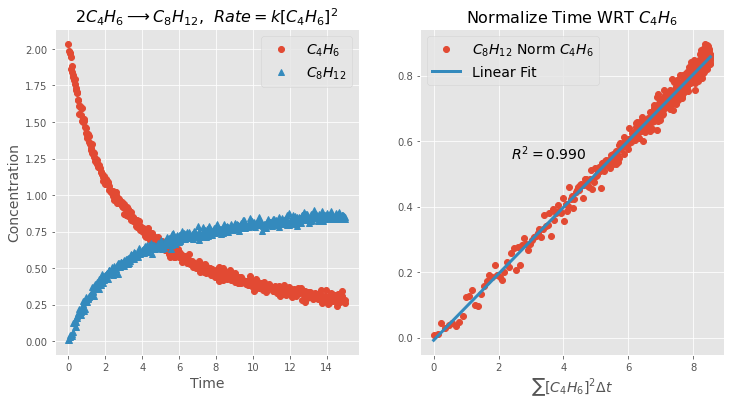

In [290]:
np.random.seed(0)

o = 2
noise = 0.02
k = 0.1
time = np.linspace(0, 15, 500)
dts = time[1:] - time[:-1]
C4H6 = [2.0]
C8H12 = [0.]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*C4H6[i]**o
    # calculate the amount of each species
    C4H6.append(C4H6[i] - dt * 2 * rate)
    C8H12.append(C8H12[i] + dt * rate)

C4H6, C8H12 = (np.array(C4H6) + np.random.normal(0,noise,len(time)), 
               np.array(C8H12) + np.random.normal(0,noise,len(time)))

# replace all negative values of the signals with 0, since these sometimes produce NaN during normalization
replace_neg(C4H6, val=0), replace_neg(C8H12, val=0)

# plot it    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(time, C4H6, 'o', label="$C_4H_6$")
ax1.plot(time, C8H12, '^', label="$C_8H_{12}$")
ax1.set_title("$2C_4H_6 \longrightarrow C_8H_{12}$,  $Rate=k[C_4H_6]^2$", fontsize=16)
ax1.set_xlabel("Time", fontsize=14)
ax1.set_ylabel("Concentration", fontsize=14)
ax1.legend(fontsize=14)

t_norm =  normalize_time(time, C4H6, 2)
ax2.plot(t_norm, C8H12, 'o', label='$C_8H_{12}$ Norm $C_4H_6$')
line = LinearRegression().fit(t_norm.reshape(-1,1), C8H12)
ax2.plot(t_norm, line.predict(t_norm.reshape(-1,1)), label="Linear Fit", linewidth=3)
ax2.text(0.3, 0.6, "$R^2={:.3f}$".format(line.score(t_norm.reshape(-1,1), C8H12)),
        transform=ax2.transAxes, fontsize=14)
ax2.set_title('Normalize Time WRT $C_4H_6$', fontsize=16)
ax2.set_xlabel('$\sum{[C_4H_6]^2\Delta t}$', fontsize=14)
ax2.legend(loc='upper left', fontsize=14)
plt.show()

## a.) An Exhaustive Search of Possible Orders

**This actually doesn't work for rate laws with more than one reagent,** since it only gives us the overall order, and does not allow us to determine the order in each reagent.  From the surface plot below, for example, we see that the reaction trace is normalized to its best linear fit for all combinations of reaction orders that sum to 3 and not just for the correct combination of 2 for $NO$ and 1 for $O_2$. In order to determine the order in individual reagents, we must simultaneously normalize two reaction traces that differ in the concentration of that reagent such that they overlay, which is the basis for VTNA.

In [296]:
np.random.seed(0)

k = 2
time = np.linspace(0, 10, 1000)
dts = time[1:] - time[:-1]
NO = [2]
O2 = [1]
NO2 = [0]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*NO[i]**2*O2[i]
    
    # calculate the amount of each species
    NO.append(NO[i] - dt * 2 * rate)
    O2.append(O2[i] - dt * rate)
    NO2.append(NO2[i] + dt * 2 * rate)

NO, O2, NO2 = np.array(NO), np.array(O2), np.array(NO2)
NO += np.random.normal(0,0.02,len(time))
O2 += np.random.normal(0,0.02,len(time))
NO2 += np.random.normal(0,0.02,len(time))

# replace all negative values of the signals with 0, since these sometimes produce NaN during normalization
replace_neg(NO, val=0)
replace_neg(O2, val=0)

rs = []
bestr = 0
besto = np.array([0,0])
best_norm = None
best_line = None
res=0.05
maxo = 2.5
mino = 0.5

concs = np.array([NO, O2]).T

NO2 = NO2.reshape(-1,1)

for O2_order in np.arange(mino, maxo, res):
    for NO_order in np.arange(mino, maxo, res):
        # normalize product (O2) time axis wrt N2O5 with guessed value for order
        t_norm =  normalize_time(time, concs, np.array([NO_order,O2_order]))
        t_norm = t_norm.reshape(-1,1)

        # perform linear regression and calculate R^2
        line = LinearRegression()  
        line.fit(t_norm, NO2)
        r = line.score(t_norm, NO2)
        rs.append(line.score(t_norm, NO2))

        if abs(r) > abs(bestr):
            bestr = r
            best_norm = t_norm
            besto = np.array([NO_order, O2_order])
            best_line = line
print("Optimal Reaction Orders:\nNO: {:.3f}\nO2: {:.3f}\n\nR-squared: {:.3f}".format(besto[0], besto[1], bestr))

Optimal Reaction Orders:
NO: 0.950
O2: 2.100

R-squared: 0.991


In [300]:
rs = np.array(rs)
rs.shape
RS = rs.reshape(40,40)

In [301]:
ONO, OO2 = np.meshgrid(np.arange(0.5, 2.5, res), np.arange(0.5, 2.5, res))

Text(0.5, 0, 'O2 Order')

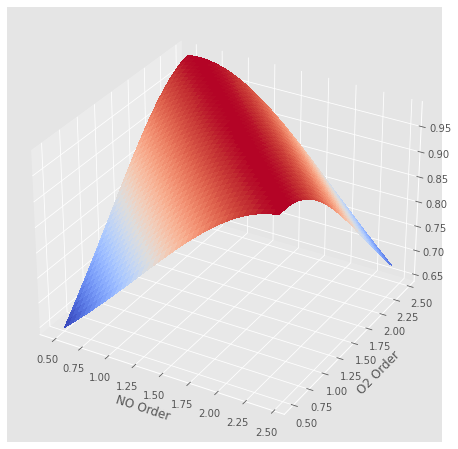

In [304]:
from matplotlib import cm
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(ONO, OO2, RS, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_xlabel('NO Order')
ax.set_ylabel('O2 Order')

## Simulate  Reactions with Varying Reactant Concentrations:

We will do this for the reaction:

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

The starting concentrations are (in arbitrary units):


|Reaction| [NO]     |   [O$_2$]| [NO$_2$]|
|--------|----------|----------|----------|
| 1      |   2      |   1      |    0     |
| 2      |   3      |   1      |    0     |

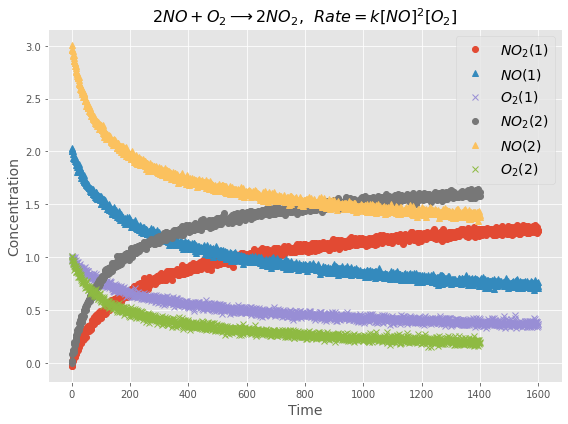

In [307]:
np.random.seed(0)

# Reaction 1: [NO] = 2

k = 0.001
time1 = np.linspace(0, 1600, 1600)
dts = time1[1:] - time1[:-1]
NO_1 = [2]
O2_1 = [1]
NO2_1 = [0]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*NO_1[i]**2*O2_1[i]**2
    
    # calculate the amount of each species
    NO_1.append(NO_1[i] - dt * 2 * rate)
    O2_1.append(O2_1[i] - dt * rate)
    NO2_1.append(NO2_1[i] + dt * 2 * rate)

NO_1, O2_1, NO2_1 = np.array(NO_1), np.array(O2_1), np.array(NO2_1)
NO_1 += np.random.normal(0,0.02,len(time1))
O2_1 += np.random.normal(0,0.02,len(time1))
NO2_1 += np.random.normal(0,0.02,len(time1))
 
# reaction 2
time2 = np.linspace(0, 1400, 1400)
dts = time2[1:] - time2[:-1]
NO_2 = [3]
O2_2 = [1]
NO2_2 = [0]

# simulate the reaction
for i, dt in enumerate(dts):
    # calculate the rate
    rate = k*NO_2[i]**2*O2_2[i]**2
    
    # calculate the amount of each species
    NO_2.append(NO_2[i] - dt * 2 * rate)
    O2_2.append(O2_2[i] - dt * rate)
    NO2_2.append(NO2_2[i] + dt * 2 * rate)

NO_2, O2_2, NO2_2 = np.array(NO_2), np.array(O2_2), np.array(NO2_2)
NO_2 += np.random.normal(0,0.02,len(time2))
O2_2 += np.random.normal(0,0.02,len(time2))
NO2_2 += np.random.normal(0,0.02,len(time2))

# plot it    
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.plot(time1, NO2_1, 'o', label="$NO_2 (1)$")
ax1.plot(time1, NO_1, '^', label="$NO (1)$")
ax1.plot(time1, O2_1, 'x', label="$O_2 (1)$")
ax1.plot(time2, NO2_2, 'o', label="$NO_2 (2)$")
ax1.plot(time2, NO_2, '^', label="$NO (2)$")
ax1.plot(time2, O2_2, 'x', label="$O_2 (2)$")
ax1.set_title("$2NO + O_2 \longrightarrow 2NO_2$,  $Rate=k[NO]^2[O_2]$", fontsize=16)
ax1.set_xlabel("Time", fontsize=14)
ax1.set_ylabel("Concentration", fontsize=14)
ax1.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [311]:
from vtna.vtna import order_search

Best fit achieved for an order of 1.97.


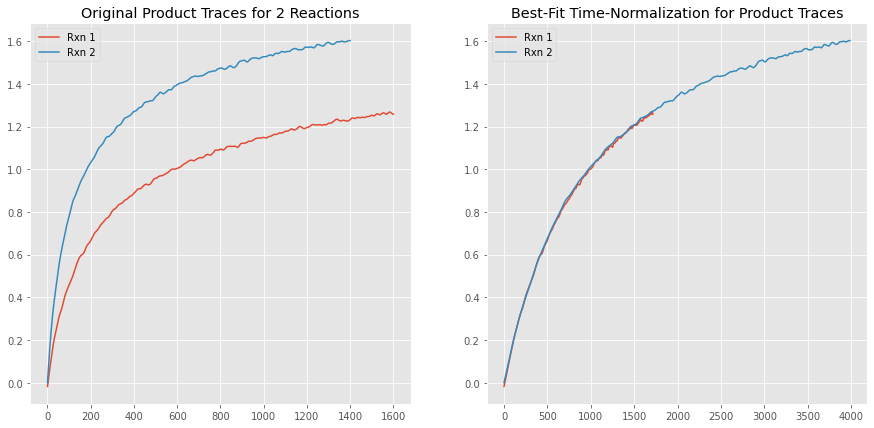

<Figure size 432x288 with 0 Axes>

In [312]:
besto, rs = order_search(time1, time2, NO2_1, NO2_2, NO_1, NO_2, o_range=(1,3), o_step=0.01, 
               to_smooth=True, win1=40, win2=40, plot=True, truncate=False, 
               overlap_thresh=0.25, figsize=(15,7))

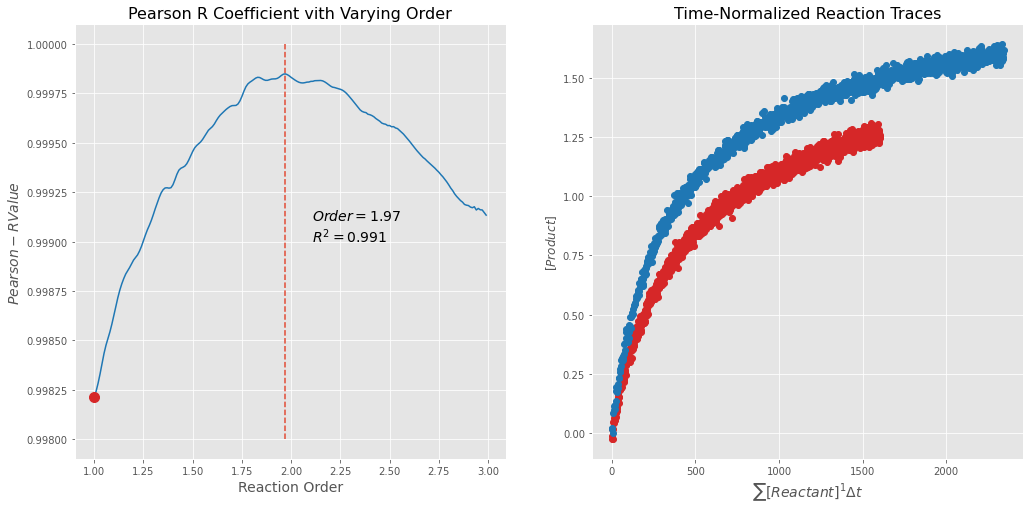

In [313]:
orders = np.arange(1, 3, 0.01)  # the trial space of reaction orders
idx = 0

# do it with smoothed traces??
# prod1 = smooth(prod1, window_len=win1, window='blackman')
# prod2 = smooth(prod2, window_len=win2, window='blackman')
# reac1 = smooth(reac1, window_len=win1, window='blackman')
# reac2 = smooth(reac2, window_len=win2, window='blackman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))
ax1.set_title('Pearson R Coefficient vith Varying Order', fontsize=16)
ax1.set_xlabel('Reaction Order', fontsize=14)
ax1.set_ylabel('$Pearson-R Value$', fontsize=14)
vline = ax1.vlines(besto, ymin=0.998, ymax=1.0, linestyles='--')
text = ax1.text(0.55, 0.5, "$Order={:.2f}$ \n$R^2={:.3f}$".format(besto, bestr), transform=ax1.transAxes, fontsize=14)
r2line = ax1.plot(orders, rs[:len(orders)], color='tab:blue', label='Search Space')[0]
coord = ax1.plot([1], [rs[idx]], 'o', color='tab:red', markersize=10, label="Current Try")[0]

# plot the initial scatter from time norm
t1_norm =  normalize_time(time1, NO_1, orders[0])
t2_norm =  normalize_time(time2, NO_2, orders[0])
vtna1 = ax2.plot(t1_norm, NO2_1, 'o', color='tab:red', label="$[Reactant]=0.2\mu M$")[0]
vtna2 = ax2.plot(t2_norm, NO2_2, 'o', color='tab:blue', label="$[Reactant]=0.3\mu M$")[0]
ax2.set_title('Time-Normalized Reaction Traces', fontsize=16)
ax2.set_xlabel(r'$\sum{{[Reactant]^{}\Delta t}}$'.format(1), fontsize=14)
ax2.set_ylabel("$[Product]$")

# keep track of all plotted data
patches = [vline] + [text] + [r2line] + [coord] + [vtna1] + [vtna2]

def init():
    ax1.legend(fontsize=14)
    ax2.legend(fontsize=14)
    return patches

def update(order):
    global idx
    
    idx += 1
    
    # a. normalize the time axis of both signals
    t1_norm = normalize_time(time1, NO_1, order)
    t2_norm = normalize_time(time2, NO_2, order)
        
    coord.set_data([order], rs[idx])
    
    vtna1.set_data(t1_norm, NO2_1)
    vtna2.set_data(t2_norm, NO2_2)
    
    ax2.set_xlim(min(t1_norm[0], t2_norm[0]) - 0.1, max(t1_norm[-1], t2_norm[-1]) * 1.1)
    ax2.set_xlabel(r'$\sum{{[Reactant]^{{{:.2f}}}\Delta t}}$'.format(order), fontsize=14)
    ax2.figure.canvas.draw()

    
    return patches

ani = FuncAnimation(fig, update, frames=orders[1:], interval=20, init_func=init, blit=False)

In [314]:
HTML(ani.to_html5_video())

In [316]:
idx = 0
ani.save('figures/VTNA_2rxn_search.gif', writer='imagemagick', fps=50)

## Attempt at alternative smoothing method

The one used now extends the two ends of the data by reflecting their points across a horizontal axis extending through the two terminal points of the data.  This creates artifacts of the data "curving up" on  both ends since the actual data is strictly concave down. This second method tries to mitigate that effect by instead extending the two ends of the data linearly via a least squares regression line through the terminal points.